## Library

In [2]:
from wass2s import *
import datetime
import importlib
from pathlib import Path
import warnings
import gc
warnings.filterwarnings("ignore")

#### Set forecast working directory

In [3]:
# Set forecast working directory
dir_s2s = "./PRCP_AMJ_2026_ic_1/"
logopath = './utilities/cilss.png'#'./utilities/agrhymet_logo_combined_reversed.png'
fcst_labels = ["BELOW-AVERAGE", "NEAR-AVERAGE", "ABOVE-AVERAGE"]#["EN DESSOUS DE LA MOYENNE", "PROCHE DE LA MOYENNE", "AU DESSUS DE LA MOYENNE"]
dist_method="bestfit" # nonparam or bestfit

In [4]:
dir_s2s = Path(dir_s2s)
os.makedirs(dir_s2s, exist_ok=True)
### Save consolidated results
hdcst_consolidated = {}
hdcst_consolidated_prob = {}
fcst_consolidated = {}
fcst_consolidated_prob = {}
scores_consolidated = {}
### Save score
dir_save_score = f"{dir_s2s}/scores"
os.makedirs(dir_save_score, exist_ok=True)
### Save forecasts
dir_to_forecast = f"{dir_s2s}/forecasts"
os.makedirs(dir_to_forecast, exist_ok=True)

#### Set Climatological Years

In [5]:
# Set Climatological Years
clim_year_start = 1994 #1991
clim_year_end = 2016 #2020

## Download Observation and Process 


#### Load Downloader 

In [6]:
# Load WAS_S2S downloader class
downloader = WAS_Download()

In [7]:
# Filter observation names to identify precipitation-related models
variables_obs = [key for key in downloader.AgroObsName().keys() if "PRCP" in key]

# Specify the directory to save downloaded model data
dir_to_save_Obs = f"{dir_s2s}/Observation"

# choose sequence corresponding to seasonal forecast targets (JAS season in this case)
season_obs = ["04", "05", "06"]  # July-August-September forecast period

# Define the observation period (years 1993 to 2016)
year_start = 1991
year_end = 2025

# Set the bounding box for the area of interest (latitude and longitude bounds)
extent_obs = [12, -3.5, 4, 1.5]  # [Northern, Western, Southern and Eastern] 

# Specify whether to overwrite existing files when downloading data
force_download = False

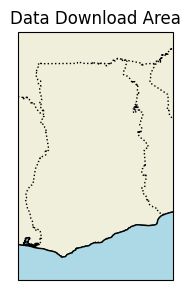

In [8]:
plot_map([extent_obs[1],extent_obs[3],extent_obs[2],extent_obs[0]], title="Data Download Area", fig_size=(4,3))

In [9]:
downloader.WAS_Download_AgroIndicators(
    dir_to_save_Obs,
    variables_obs,
    year_start,
    year_end,
    extent_obs,
    season_obs,
    force_download
)

Attempt 1/3: Downloading precipitation_flux for 1991 months=['03', '04', '05']


2026-02-09 22:34:56,103 INFO [2025-12-02T00:00:00] Please be aware that from 1st January 2026, scientific and technical support of this dataset will not be available anymore. Therefore, it is not recommended for use in a production environment. For updates please watch the [forum announcement](https://forum.ecmwf.int/t/scientific-and-technical-support-for-agera5-ending-from-31-12-2025/14468)
2026-02-09 22:34:56,105 INFO Request ID is 426f4f1a-b1df-45a9-92c2-ea54b3bd732d
2026-02-09 22:34:56,394 INFO status has been updated to accepted
2026-02-09 22:35:10,813 INFO status has been updated to successful


44782b33505d9e808f1c6871ff9a9ace.zip:   0%|          | 0.00/2.47M [00:00<?, ?B/s]

Deleted ZIP file: PRCP_MAM_2026_ic_1/Observation/Obs_PRCP_1991_MarAprMay_partA.zip
Attempt 1/3: Downloading precipitation_flux for 1992 months=['03', '04', '05']


2026-02-09 22:35:20,669 INFO [2025-12-02T00:00:00] Please be aware that from 1st January 2026, scientific and technical support of this dataset will not be available anymore. Therefore, it is not recommended for use in a production environment. For updates please watch the [forum announcement](https://forum.ecmwf.int/t/scientific-and-technical-support-for-agera5-ending-from-31-12-2025/14468)
2026-02-09 22:35:20,670 INFO Request ID is 03fbd636-e90d-43d0-aeb9-6b16cfba14a1
2026-02-09 22:35:20,946 INFO status has been updated to accepted
2026-02-09 22:35:30,257 INFO status has been updated to running
2026-02-09 22:35:35,581 INFO status has been updated to successful


...

ce0ebd5cbfee43f3a46f94f850cac130.zip:   0%|          | 0.00/2.45M [00:00<?, ?B/s]

Deleted ZIP file: PRCP_MAM_2026_ic_1/Observation/Obs_PRCP_2024_MarAprMay_partA.zip
Attempt 1/3: Downloading precipitation_flux for 2025 months=['03', '04', '05']


2026-02-09 22:52:12,680 INFO [2025-12-02T00:00:00] Please be aware that from 1st January 2026, scientific and technical support of this dataset will not be available anymore. Therefore, it is not recommended for use in a production environment. For updates please watch the [forum announcement](https://forum.ecmwf.int/t/scientific-and-technical-support-for-agera5-ending-from-31-12-2025/14468)
2026-02-09 22:52:12,681 INFO Request ID is d03f72cd-7a24-493e-8d02-f706365507a0
2026-02-09 22:52:12,854 INFO status has been updated to accepted
2026-02-09 22:52:21,874 INFO status has been updated to running
2026-02-09 22:52:27,109 INFO status has been updated to successful


e3ed5c2e37041f336492ec36c36468e4.zip:   0%|          | 0.00/2.45M [00:00<?, ?B/s]

Deleted ZIP file: PRCP_MAM_2026_ic_1/Observation/Obs_PRCP_2025_MarAprMay_partA.zip
Saved final dataset for AGRO.PRCP to: PRCP_MAM_2026_ic_1/Observation/Obs_PRCP_1991_2025_MarAprMay.nc


In [11]:
#### Process predictant
rainfall = prepare_predictand(dir_to_save_Obs, variables_obs, year_start, year_end, season_obs, ds=False, daily=False)
season_str = "".join([calendar.month_abbr[int(month)] for month in season_obs])

#### Process Obs in combining with Seasonal cumulative Ground-Observation

In [12]:
# ## Path to the CPT file
cpt_input_file_path = "./AMJ_1981-2025.csv"

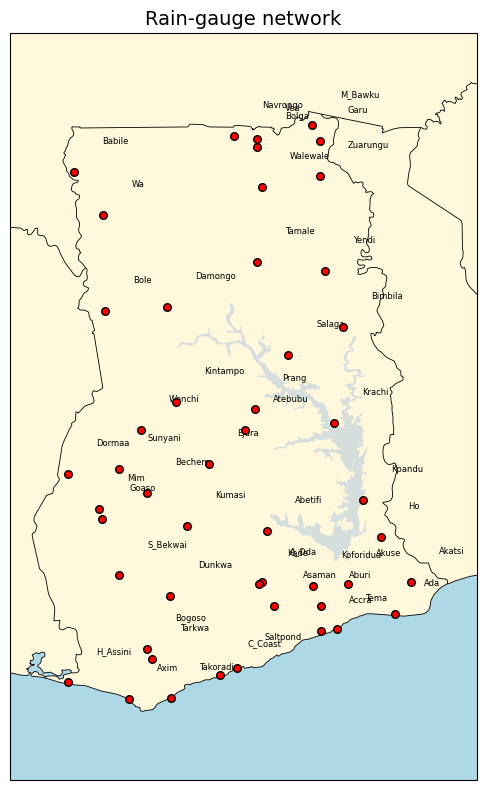

In [13]:
# ## Read CSV
df = pd.read_csv(cpt_input_file_path, na_values=-999.0,  encoding="latin1")
df_filtered = df[(df['STATION'] == 'LAT') | (df['STATION'] == 'LON') | 
                 (pd.to_numeric(df['STATION'], errors='coerce').between(year_start, year_end))]
verify_station_network(df_filtered, extent_obs)

In [14]:
da = prepare_predictand(dir_to_save_Obs, variables_obs, year_start, year_end, season_obs,  ds=False).sel(T=slice(str(year_start),str(year_end)))

In [15]:
### ## Instantiate WAS_Merging class
path_ = Path(dir_s2s / "rainfall_predictand.nc")
data_merger = WAS_Merging(df_filtered, da, date_month_day= '04-01')
if path_.is_file():
    rainfall__ = xr.load_dataarray(path_)
else:
    rainfall__, _ = data_merger.simple_bias_adjustment(do_cross_validation=False)
    rainfall__.to_netcdf(path_)


Year = 1991-04-01T00:00:00.000000000, number in-situ = 48

Year = 1992-04-01T00:00:00.000000000, number in-situ = 48

Year = 1993-04-01T00:00:00.000000000, number in-situ = 48

Year = 1994-04-01T00:00:00.000000000, number in-situ = 46

Year = 1995-04-01T00:00:00.000000000, number in-situ = 48

Year = 1996-04-01T00:00:00.000000000, number in-situ = 49

Year = 1997-04-01T00:00:00.000000000, number in-situ = 49

Year = 1998-04-01T00:00:00.000000000, number in-situ = 48

Year = 1999-04-01T00:00:00.000000000, number in-situ = 46

Year = 2000-04-01T00:00:00.000000000, number in-situ = 49

Year = 2001-04-01T00:00:00.000000000, number in-situ = 49

Year = 2002-04-01T00:00:00.000000000, number in-situ = 49

Year = 2003-04-01T00:00:00.000000000, number in-situ = 49

Year = 2004-04-01T00:00:00.000000000, number in-situ = 49

Year = 2005-04-01T00:00:00.000000000, number in-situ = 48

Year = 2006-04-01T00:00:00.000000000, number in-situ = 48

Year = 2007-04-01T00:00:00.000000000, number in-situ = 

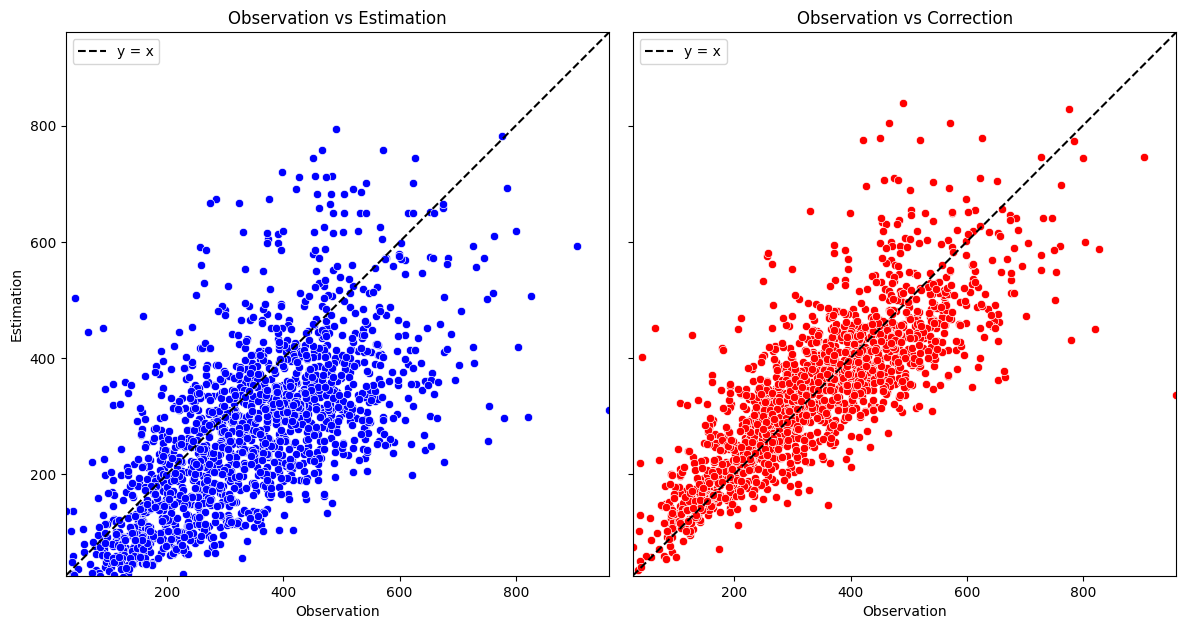

In [16]:
data_merger.plot_merging_comparaison(df_filtered, da, rainfall__)

In [17]:
rainfall = rainfall__
rainfall.name = "PRCP"

#### Identify the parametric distribution that best fits the observations

In [18]:
if dist_method=="nonparam":
    pass
else:
    transf = WAS_TransformData(rainfall.sel(T=slice(str(clim_year_start),str(clim_year_end))), 
                      distribution_map={'norm': 1, 'lognorm': 2, 'gamma': 4,}, #'norm': 1, 'lognorm': 2, 'expon': 3, 'gamma': 4, 'weibull_min': 5, 't_dist': 6, "poisson":7, "nbinom":8 
                                n_clusters=1000)
    best_code_da, best_shape_da, best_loc_da, best_scale_da, _ = transf.fit_best_distribution(mode="grid")

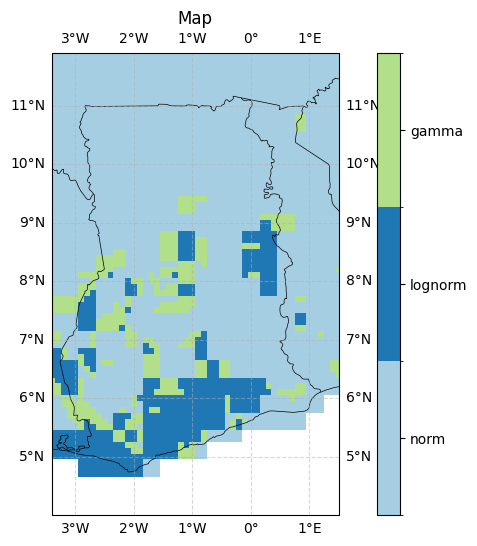

In [19]:
if dist_method=="bestfit":
    transf.plot_best_fit_map(best_code_da,
                             {'norm': 1, 'lognorm': 2, 'expon': 3, 'gamma': 4,
                              'weibull_min': 5, 't_dist': 6, "poisson":7, "nbinom":8},
                             show_plot=True)

# 1st - Approach: Skill-Verified, Machine Learning–Calibrated Multi-Model Ensemble (SV-ML-CMME)

In [20]:
# Filter model names to identify precipitation-related models
center_variable = [key for key in downloader.ModelsName().keys() if "PRCP" in key]
# center_variable.remove('UKMO_603.PRCP')
# center_variable.remove('DWD_21.PRCP')
# center_variable.remove('METEOFRANCE_8.PRCP')
# Specify the directory to save downloaded model data
dir_to_save_model = f"{dir_s2s}/model_data"

# Define the month for model initialization (June)
month_of_initialization = "01"

# Define lead times corresponding to seasonal forecast targets (JAS season in this case)
lead_time = ["02", "03", "04"]  # July-August-September forecast period

# Define the hindcast period for model data (years 1993 to 2016)
year_start_model = 1993
year_end_model = 2016

# Set the bounding box for the area of interest (latitude and longitude bounds)
extent = [12, -3.5, 4, 1.5] # [Northern, Western, Southern and Eastern] 

# Define if you want to download forecast or hindcast
forecast = None

# Define if you want all members of ensemble or doing an ensemble mean
ensemble_mean = "mean"

# Specify whether to overwrite existing files when downloading data
force_download = False

In [21]:
hindcast_files = downloader.WAS_Download_Models(
    dir_to_save_model,
    center_variable,
    month_of_initialization,
    lead_time,
    year_start_model,
    year_end_model,
    extent, 
    forecast,
    ensemble_mean,
    force_download)

2026-02-09 23:05:40,176 INFO Request ID is e884d227-8ef3-434e-bfaa-620c59783719
2026-02-09 23:05:40,557 INFO status has been updated to accepted
2026-02-09 23:05:50,289 INFO status has been updated to running
2026-02-09 23:05:55,539 INFO status has been updated to successful


7fba88227593e1a7359e24f0d1798dde.nc:   0%|          | 0.00/260k [00:00<?, ?B/s]

Downloaded: PRCP_MAM_2026_ic_1/model_data/hindcast_bom2_PRCP_JanIc_MarAprMay_02.nc
Deleted not process file: PRCP_MAM_2026_ic_1/model_data/hindcast_bom2_PRCP_JanIc_MarAprMay_02.nc
Download finished, combined dataset for bom 2 PRCP to PRCP_MAM_2026_ic_1/model_data/hindcast_bom2_PRCP_JanIc_MarAprMay_02.nc


2026-02-09 23:06:00,203 INFO Request ID is 5c53702b-dc1d-4d44-85a5-cde63ab33717
2026-02-09 23:06:00,379 INFO status has been updated to accepted
2026-02-09 23:06:22,919 INFO status has been updated to successful


2a6051df5077f4bdd49655b13bea4029.nc:   0%|          | 0.00/219k [00:00<?, ?B/s]

...

Download finished for ncar_ccsm4 1 precip to PRCP_MAM_2026_ic_1/model_data/hindcast_ncarccsm41_PRCP_JanIc_MarAprMay_02.nc
URL returned status code 404. Skipping download.
failed to download ncar_cesm1_precip_hcst_Janic_3-5_1992-2021.txt


ncar_cesm1_precip_hcst_Janic_3-5_1991-2020.txt: 22.2MB [01:23, 265kB/s] 


Download finished for ncar_cesm1 1 precip to PRCP_MAM_2026_ic_1/model_data/hindcast_ncarcesm11_PRCP_JanIc_MarAprMay_02.nc
URL returned status code 404. Skipping download.
failed to download nmme_precip_hcst_Janic_3-5_1992-2021.txt


nmme_precip_hcst_Janic_3-5_1991-2020.txt: 22.3MB [01:42, 217kB/s] 


Download finished for nmme 1 precip to PRCP_MAM_2026_ic_1/model_data/hindcast_nmme1_PRCP_JanIc_MarAprMay_02.nc


In [22]:
forecast = 2026

In [23]:
forecast_files = downloader.WAS_Download_Models(
    dir_to_save_model,
    center_variable,
    month_of_initialization,
    lead_time,
    year_start_model,
    year_end_model,
    extent, 
    forecast,
    ensemble_mean,
    force_download)

2026-02-09 23:23:41,648 INFO Request ID is 5af2320f-1e96-4b6d-b456-68f6898df0d8
2026-02-09 23:23:42,067 INFO status has been updated to accepted
2026-02-09 23:23:56,497 INFO status has been updated to successful


b9d41165c9f4431f44b2aee80254ac1a.nc:   0%|          | 0.00/70.5k [00:00<?, ?B/s]

Downloaded: PRCP_MAM_2026_ic_1/model_data/forecast_bom2_PRCP_JanIc_MarAprMay_02.nc
Deleted not process file: PRCP_MAM_2026_ic_1/model_data/forecast_bom2_PRCP_JanIc_MarAprMay_02.nc
Download finished, combined dataset for bom 2 PRCP to PRCP_MAM_2026_ic_1/model_data/forecast_bom2_PRCP_JanIc_MarAprMay_02.nc


2026-02-09 23:24:01,527 INFO Request ID is ba2b8869-df23-4074-8edc-a3d0756db266
2026-02-09 23:24:01,960 INFO status has been updated to accepted
2026-02-09 23:24:24,028 INFO status has been updated to running
2026-02-09 23:24:35,583 INFO status has been updated to successful


19cdc38f06e8e588360f1ba9268ae6f6.nc:   0%|          | 0.00/44.0k [00:00<?, ?B/s]

...

Download finished for ncar_ccsm4 1 precip to PRCP_MAM_2026_ic_1/model_data/forecast_ncarccsm41_PRCP_JanIc_MarAprMay_02.nc


ncar_cesm1_precip_fcst_Janic_3-5_2026-2026.txt: 740kB [00:01, 556kB/s] 


Download finished for ncar_cesm1 1 precip to PRCP_MAM_2026_ic_1/model_data/forecast_ncarcesm11_PRCP_JanIc_MarAprMay_02.nc


nmme_precip_fcst_Janic_3-5_2026-2026.txt: 743kB [00:01, 485kB/s] 

Download finished for nmme 1 precip to PRCP_MAM_2026_ic_1/model_data/forecast_nmme1_PRCP_JanIc_MarAprMay_02.nc


In [24]:
hindcast_files = {k: hindcast_files[k] for k in hindcast_files.keys() & forecast_files.keys()}
forecast_files = {k: forecast_files[k] for k in hindcast_files.keys() & forecast_files.keys()}
common_keys = {k.lower() for k in hindcast_files} & {k.lower() for k in forecast_files}
center_variable = [
    item
    for item in center_variable
    if any(item.lower().startswith(k) for k in list(common_keys))
                ]

In [25]:
was_verify = WAS_Verification(dist_method=dist_method, mae_rmse_crps_thrsd=200)

#### Validation of GCM

In [26]:
score = ["Pearson", "MAE"]

Pearson Correlation


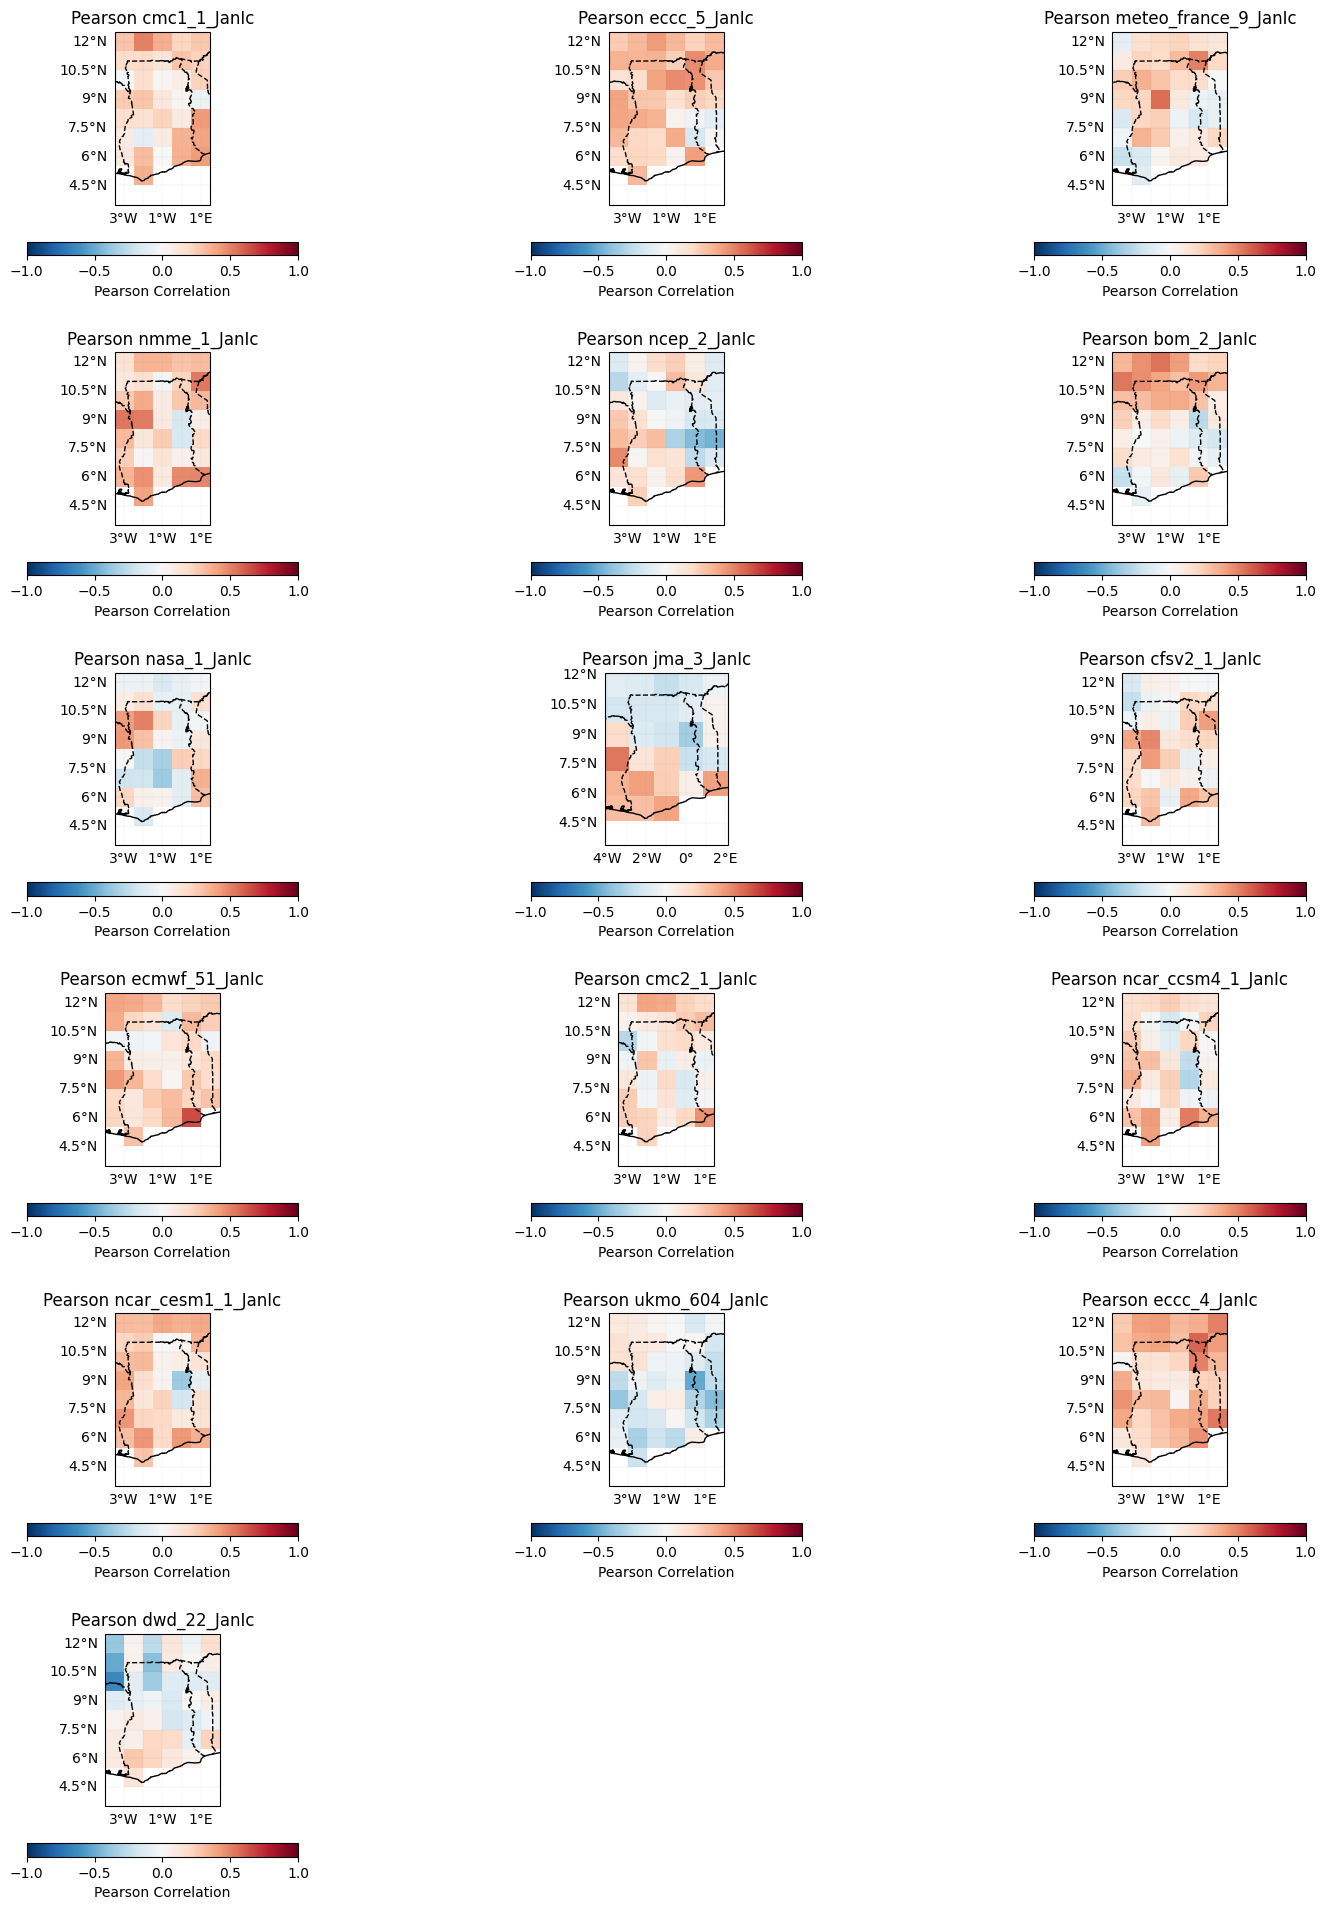

Mean Absolute Error


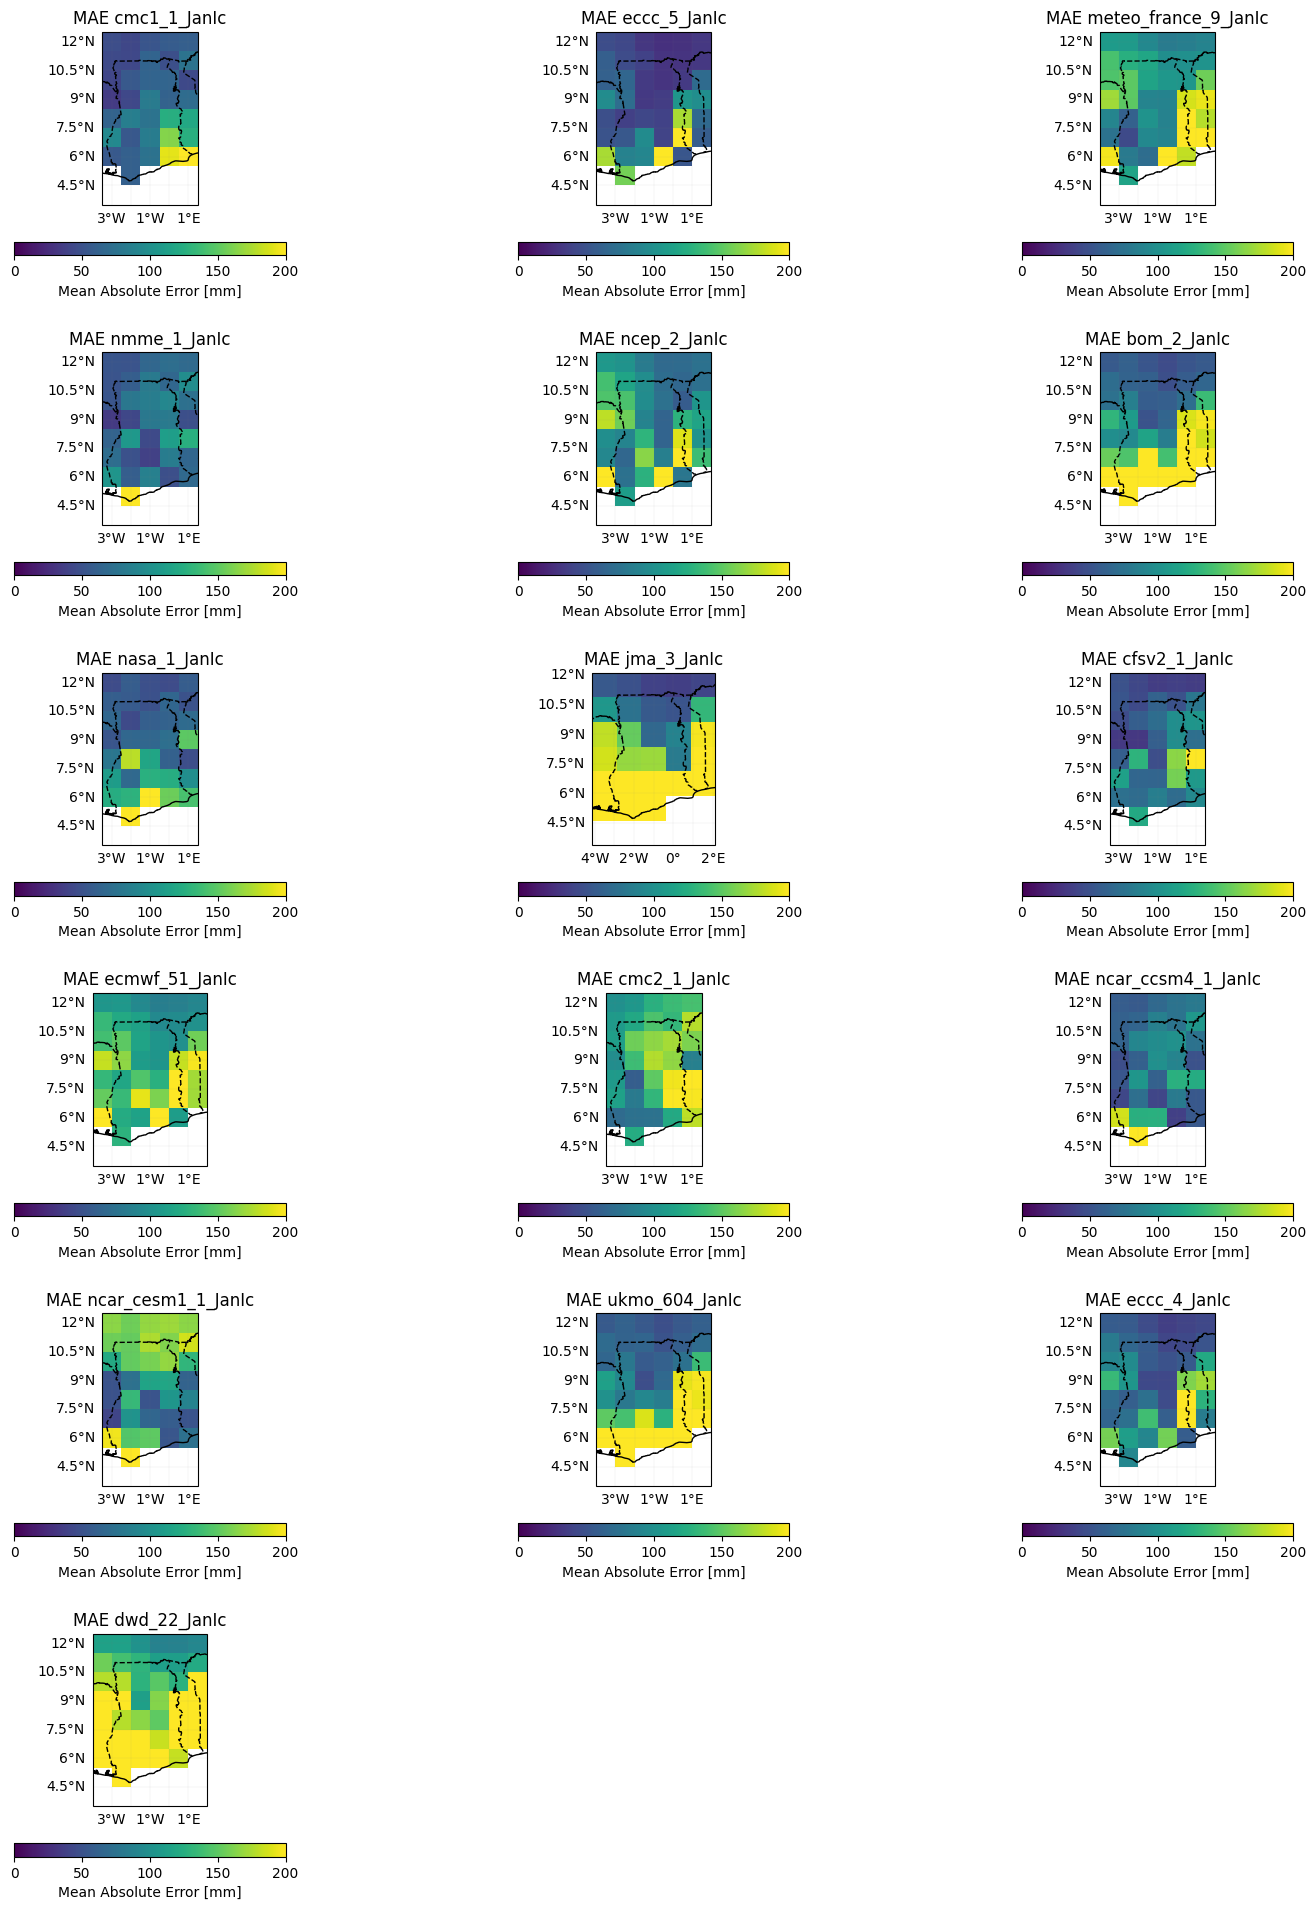

In [27]:
# score.append('GROC') if 'GROC' not in score else score
os.makedirs(dir_save_score, exist_ok=True)
scores = {}
for i in score:
    scores[i] = was_verify.gcm_validation_compute(hindcast_files, rainfall, i, month_of_initialization, clim_year_start, clim_year_end, dir_save_score, lead_time = None, ensemble_mean=None, gridded=True)
    print(was_verify.scores[i][0])
    was_verify.plot_models_score(scores[i], i, dir_save_score)
    r = scores[i]

# SV-ML-CMME

## Choice of best GCM models

In [29]:
best_models = get_best_models(center_variable, scores, metric='MAE', threshold=150, top_n=8, gcm=True)
best_models 

['ECCC_5.PRCP',
 'ECCC_4.PRCP',
 'NMME_1.PRCP',
 'NCEP_2.PRCP',
 'NCAR_CCSM4_1.PRCP',
 'CMC1_1.PRCP',
 'CFSV2_1.PRCP',
 'NASA_1.PRCP']

In [30]:
%load_ext autoreload
%autoreload 2

### MLP

In [31]:
# from scipy.stats import loguniform
model = WAS_mme_MLP(
    hidden_layer_sizes_range=[
        (2,2), (3,2), (2,4), (4,2),
        (5,2), (5,5), (5,5,5),
        (8,4), (16,8), (16,8,4),
        # (15,10,5,2),
        # (30,), (50,),              # Moderate baseline
        # (60, 30), (100, 50),       # Compression funnels
        # (30, 15, 5)                # Deep funnel for complex non-linearities
    ],
    learning_rate_init_range=loguniform(1e-4, 1e-1),
    activation_options=['tanh'],# 'identity'],        
    solver_options=['adam','sgd'],#, 'lbfgs'],  # sgd, lbfgs         
    alpha_range=loguniform(1e-5, 1e-1),   
    search_method='bayesian',                              
    random_state=42,
    n_iter_search=25,  
    max_iter=5000,
    cv_folds=5,
    n_clusters=2,
    dist_method=dist_method,
    optuna_n_jobs=-1,
    optuna_timeout=600
)

#### Cross-validation

In [32]:
# all_model_hdcst, all_model_fcst, obs, best_score = process_datasets_for_mme(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))), gcm=True, ELM_ELR=True, dir_to_save_model=dir_to_save_model, best_models=best_models, scores=scores, year_start=year_start_model, year_end=year_end_model, model=True, month_of_initialization=month_of_initialization, lead_time=lead_time, year_forecast=forecast)
all_model_hdcst, all_model_fcst, obs, best_score = process_datasets_for_mme(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))), hdcsted=hindcast_files, fcsted=forecast_files, scores= scores, score_metric='MAE', gcm=True, agroparam=False, ELM_ELR=False, best_models=best_models, dir_to_save_model=dir_to_save_model, year_start=year_start_model, year_end=year_end_model, model=True, month_of_initialization=month_of_initialization, lead_time=lead_time, year_forecast=forecast)

In [33]:
best_params, cluster = model.compute_hyperparameters(all_model_hdcst, obs, clim_year_start, clim_year_end)

[I 2026-02-09 23:44:33,364] A new study created in memory with name: no-name-62796a64-1331-4b77-9368-8355f77d8b58
[I 2026-02-09 23:44:38,789] Trial 0 finished with value: -1.5925187447099551 and parameters: {'hidden_layer_sizes': (2, 4), 'activation': 'tanh', 'solver': 'adam', 'learning_rate_init': 0.03789770634065806, 'alpha': 0.05122630868712078}. Best is trial 0 with value: -1.5925187447099551.
[I 2026-02-09 23:44:45,336] Trial 4 finished with value: -1.446978953500368 and parameters: {'hidden_layer_sizes': (5, 2), 'activation': 'tanh', 'solver': 'adam', 'learning_rate_init': 0.00644681434199343, 'alpha': 0.0065373953492849695}. Best is trial 4 with value: -1.446978953500368.
[I 2026-02-09 23:44:57,215] Trial 6 finished with value: -1.5263032406590478 and parameters: {'hidden_layer_sizes': (10, 5), 'activation': 'tanh', 'solver': 'sgd', 'learning_rate_init': 0.09751406691740033, 'alpha': 0.0014391961294740558}. Best is trial 4 with value: -1.446978953500368.
[I 2026-02-09 23:45:03,8

In [34]:
best_params #= {'activation': 'lin', 'neurons': 200, 'norm': 37.38460883888426}

{0.0: {'hidden_layer_sizes': (2, 2),
  'learning_rate_init': 0.00043219897910421595,
  'activation': 'tanh',
  'solver': 'sgd',
  'alpha': 4.70416723744954e-05},
 1.0: {'hidden_layer_sizes': (3, 2),
  'learning_rate_init': 0.00010142635857857799,
  'activation': 'tanh',
  'solver': 'sgd',
  'alpha': 0.06750503593545387}}

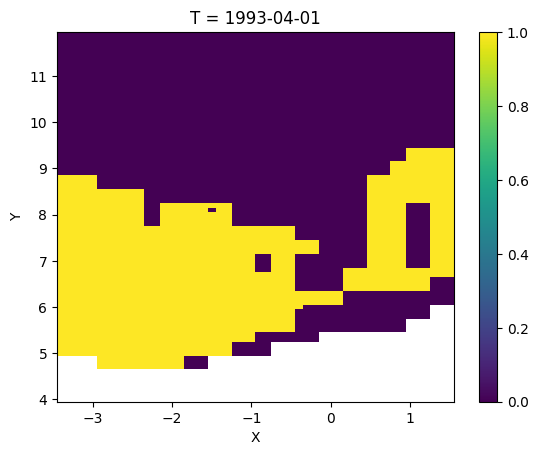

In [35]:
cluster.plot()

In [36]:
was_mme_gcm = WAS_Cross_Validator(n_splits=len(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))).get_index("T")), nb_omit=2)

In [37]:
if dist_method=="bestfit":
    hindcast_det_gcm, hindcast_prob_gcm, = was_mme_gcm.cross_validate(model, obs, all_model_hdcst, clim_year_start, 
                                                                  clim_year_end, best_params=best_params, cluster_da=cluster,
                                                                  best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
else:
    hindcast_det_gcm, hindcast_prob_gcm, = was_mme_gcm.cross_validate(model, obs, all_model_hdcst, clim_year_start,
                                                                  clim_year_end, best_params=best_params, cluster_da=cluster
                                                                     )    
hdcst_consolidated['SV-ML-CMME_MLP'] = hindcast_det_gcm
hdcst_consolidated_prob['SV-ML-CMME_MLP'] = hindcast_prob_gcm

Cross-validation ongoing


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24/24 [05:10<00:00, 12.92s/it]


In [38]:
was_verify = WAS_Verification(dist_method=dist_method, mae_rmse_crps_thrsd=250)

#### Verification

In [39]:
score = ['Pearson', 'MAE']
model_name = "MLP" #"Extreme Learning Machine" # Extreme Learning Machine "MultiLayer Perceptron" XGBoost Random Forest

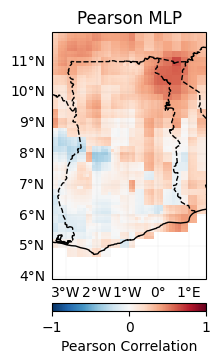

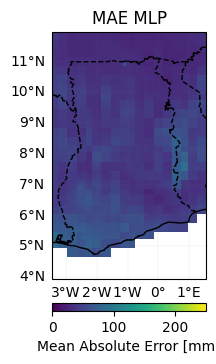

In [40]:
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        rainfall.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_det_gcm
    )
    scores_consolidated[i] = {'SV-ML-CMME_MLP': r}
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

##### Probabilistic

In [41]:
score = ['GROC', 'RPSS']

Generalized Discrimination Score


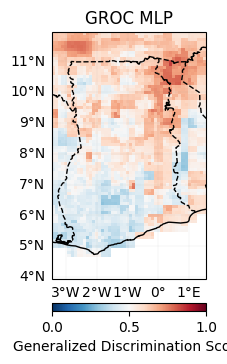

Ranked Probability Skill Score


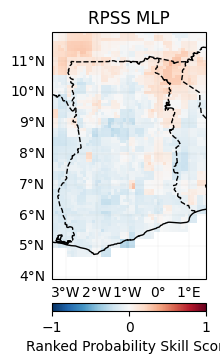

In [42]:
score = score.append('GROC') if 'GROC' not in score else score
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        rainfall.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_prob_gcm,
        clim_year_start,
        clim_year_end)
    scores_consolidated[i] = {'SV-ML-CMME_MLP': r}
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

#### Forecast 

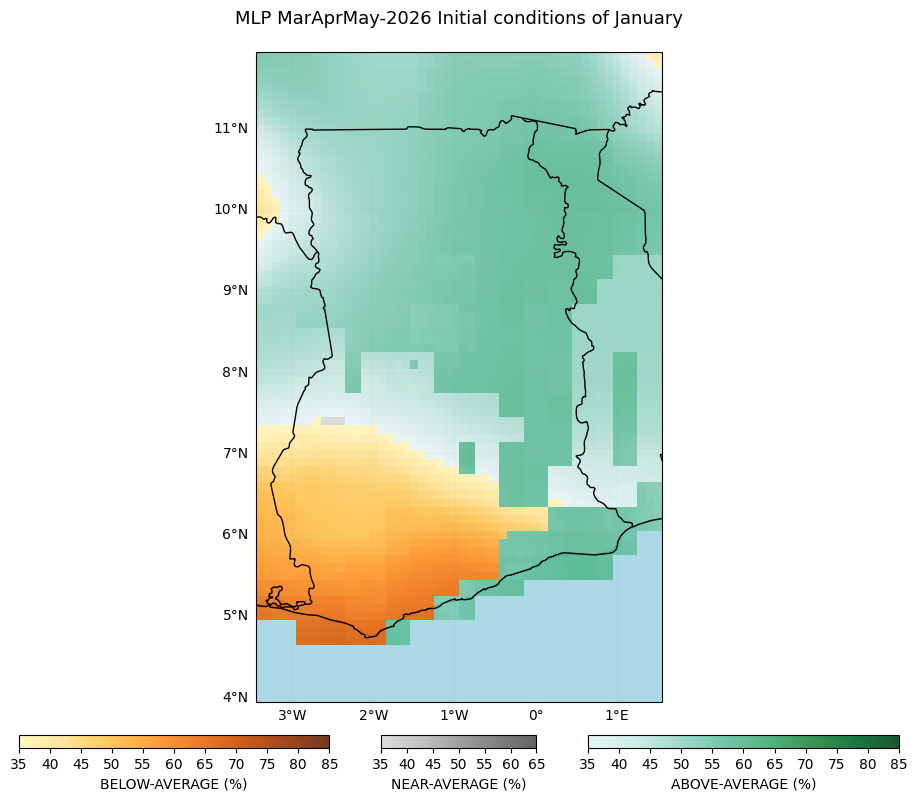

99186

In [43]:
if dist_method=="bestfit":
    forecast_det_gcm, forecast_prob_gcm= model.forecast(obs, clim_year_start, clim_year_end, all_model_hdcst, hindcast_det_gcm, all_model_fcst, best_params=best_params, cluster_da=cluster, 
                                                        best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
else:
    forecast_det_gcm, forecast_prob_gcm= model.forecast(obs, clim_year_start, clim_year_end, all_model_hdcst, hindcast_det_gcm, 
                                                        all_model_fcst, best_params=best_params, cluster_da=cluster
                                                       )
    
fcst_consolidated['SV-ML-CMME_MLP'] = forecast_det_gcm
fcst_consolidated_prob['SV-ML-CMME_MLP'] = forecast_prob_gcm
plot_prob_forecasts(f"{dir_to_forecast}", forecast_prob_gcm.drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast} Initial conditions of {calendar.month_name[int(month_of_initialization)]}",
                    hspace=0.1, labels=fcst_labels, reverse_cmap=False)
gc.collect()

### Extreme Learning

In [44]:
model = WAS_mme_hpELM(neurons_range=[5, 10, 25, 50, 100, 200, 400, 600, 800, 1000, 1500],    
                        activation_options=['sigm', 'tanh', 'lin'],# lin, 'rbf_l1', 'rbf_l2' 'rbf_linf'],
                        norm_range=loguniform(1e-2, 1e2),            
                        random_state=42,
                        n_iter_search=500,                             
                        cv_folds=5,
                        dist_method=dist_method,
                        search_method='bayesian',
                        n_clusters=3,
                        n_trials_bayesian=100,
                        bayesian_sampler='tpe', #random or tpe
                        )

#### Cross-validation

In [45]:
# all_model_hdcst, all_model_fcst, obs, best_score = process_datasets_for_mme(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))), gcm=True, ELM_ELR=True, dir_to_save_model=dir_to_save_model, best_models=best_models, scores=scores, year_start=year_start_model, year_end=year_end_model, model=True, month_of_initialization=month_of_initialization, lead_time=lead_time, year_forecast=forecast)
all_model_hdcst, all_model_fcst, obs, best_score = process_datasets_for_mme(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))), hdcsted=hindcast_files, fcsted=forecast_files, scores= scores, score_metric='MAE', gcm=True, agroparam=False, ELM_ELR=False, best_models=best_models, dir_to_save_model=dir_to_save_model, year_start=year_start_model, year_end=year_end_model, model=True, month_of_initialization=month_of_initialization, lead_time=lead_time, year_forecast=forecast)

In [46]:
best_params, cluster = model.compute_hyperparameters(all_model_hdcst, obs, clim_year_start, clim_year_end)

[I 2026-02-10 00:01:54,648] A new study created in memory with name: cluster_0.0
[I 2026-02-10 00:01:57,219] Trial 3 finished with value: -1.1951998553731091 and parameters: {'neurons': 25, 'activation': 'tanh', 'norm': 0.026120417649837118}. Best is trial 3 with value: -1.1951998553731091.
[I 2026-02-10 00:01:57,275] Trial 1 finished with value: -1.1920982331043923 and parameters: {'neurons': 25, 'activation': 'tanh', 'norm': 16.671063739209554}. Best is trial 1 with value: -1.1920982331043923.
[I 2026-02-10 00:01:57,865] Trial 5 finished with value: -1.1951748777412536 and parameters: {'neurons': 25, 'activation': 'tanh', 'norm': 0.1567954467830121}. Best is trial 1 with value: -1.1920982331043923.
[I 2026-02-10 00:01:59,486] Trial 10 finished with value: -1.1379018064602548 and parameters: {'neurons': 5, 'activation': 'lin', 'norm': 24.059250673055317}. Best is trial 10 with value: -1.1379018064602548.


processing batch 19/34, eta 0:00:04processing batch 15/34, eta 0:00:06

processing batch 28/34, eta 0:00:01
processing batch 14/34, eta 0:00:07
processing batch 16/34, eta 0:00:05
processing batch 16/34, eta 0:00:06
processing batch 8/34, eta 0:00:16
processing batch 27/34, eta 0:00:02
processing batch 22/34, eta 0:00:02
processing batch 27/34, eta 0:00:02
processing batch 23/34, eta 0:00:04
processing batch 31/34, eta 0:00:01
processing batch 18/34, eta 0:00:09
processing batch 23/34, eta 0:00:02
processing batch 18/34, eta 0:00:04
processing batch 28/34, eta 0:00:03
processing batch 33/34, eta 0:00:00
processing batch 16/34, eta 0:00:05
processing batch 14/34, eta 0:00:07
processing batch 18/34, eta 0:00:04
processing batch 26/34, eta 0:00:01
processing batch 13/34, eta 0:00:08
processing batch 30/34, eta 0:00:01
processing batch 28/34, eta 0:00:01
processing batch 30/34, eta 0:00:01
processing batch 27/34, eta 0:00:02
processing batch 19/34, eta 0:00:04
processing batch 10/34, eta 0

[I 2026-02-10 00:02:38,029] Trial 11 finished with value: -1.6753900444941927 and parameters: {'neurons': 200, 'activation': 'tanh', 'norm': 0.23404333091103044}. Best is trial 10 with value: -1.1379018064602548.
[I 2026-02-10 00:02:38,042] Trial 6 finished with value: -1.9982893858309179 and parameters: {'neurons': 200, 'activation': 'sigm', 'norm': 0.014192810355064549}. Best is trial 10 with value: -1.1379018064602548.


processing batch 26/34, eta 0:00:03
processing batch 32/34, eta 0:00:00
processing batch 19/34, eta 0:00:04


[I 2026-02-10 00:02:42,924] Trial 12 finished with value: -1.5058384994031573 and parameters: {'neurons': 50, 'activation': 'tanh', 'norm': 3.538502472613389}. Best is trial 10 with value: -1.1379018064602548.


...

[I 2026-02-10 00:16:03,747] Trial 72 finished with value: -2.684131680855542 and parameters: {'neurons': 1000, 'activation': 'tanh', 'norm': 30.30477382938742}. Best is trial 82 with value: -0.9127566787651265.
[I 2026-02-10 00:16:04,187] Trial 71 finished with value: -2.70700248345564 and parameters: {'neurons': 1000, 'activation': 'tanh', 'norm': 29.374971456422266}. Best is trial 82 with value: -0.9127566787651265.
[I 2026-02-10 00:16:05,176] Trial 84 finished with value: -0.9125154328829703 and parameters: {'neurons': 5, 'activation': 'tanh', 'norm': 69.53354460374169}. Best is trial 84 with value: -0.9125154328829703.
[I 2026-02-10 00:16:06,139] Trial 73 finished with value: -2.71913052424242 and parameters: {'neurons': 1000, 'activation': 'tanh', 'norm': 28.901647199777255}. Best is trial 84 with value: -0.9125154328829703.
[I 2026-02-10 00:16:06,467] Trial 85 finished with value: -1.2914477491335739 and parameters: {'neurons': 25, 'activation': 'tanh', 'norm': 39.109450293988274

processing batch 15/23, eta 0:00:02
processing batch 15/23, eta 0:00:02


[I 2026-02-10 00:16:07,009] Trial 74 finished with value: -2.66069408727617 and parameters: {'neurons': 1000, 'activation': 'tanh', 'norm': 31.311257770896525}. Best is trial 86 with value: -0.9124901684911562.
[I 2026-02-10 00:16:07,287] Trial 87 finished with value: -0.9125007413131154 and parameters: {'neurons': 5, 'activation': 'tanh', 'norm': 71.87946842821508}. Best is trial 86 with value: -0.9124901684911562.
[I 2026-02-10 00:16:07,390] Trial 88 finished with value: -0.9124935766722624 and parameters: {'neurons': 5, 'activation': 'tanh', 'norm': 73.02484873736523}. Best is trial 86 with value: -0.9124901684911562.
[I 2026-02-10 00:16:07,699] Trial 89 finished with value: -0.9125098341091675 and parameters: {'neurons': 5, 'activation': 'tanh', 'norm': 70.42711071533083}. Best is trial 86 with value: -0.9124901684911562.
[I 2026-02-10 00:16:08,825] Trial 90 finished with value: -0.9125231387678584 and parameters: {'neurons': 5, 'activation': 'tanh', 'norm': 68.30455986819138}. Bes

processing batch 20/23, eta 0:00:00


[I 2026-02-10 00:16:12,698] Trial 83 finished with value: -2.655682440858701 and parameters: {'neurons': 1000, 'activation': 'tanh', 'norm': 31.533907948063646}. Best is trial 91 with value: -0.9124741075300268.
[I 2026-02-10 00:16:12,778] Trial 81 finished with value: -2.7033987113713147 and parameters: {'neurons': 1000, 'activation': 'tanh', 'norm': 29.51820027967454}. Best is trial 91 with value: -0.9124741075300268.


In [47]:
best_params #= {'activation': 'lin', 'neurons': 200, 'norm': 37.38460883888426}

{0.0: {'neurons': 10, 'activation': 'sigm', 'norm': 75.8012219875167},
 1.0: {'neurons': 5, 'activation': 'tanh', 'norm': 98.87976099188879},
 2.0: {'neurons': 5, 'activation': 'tanh', 'norm': 76.14175756579685}}

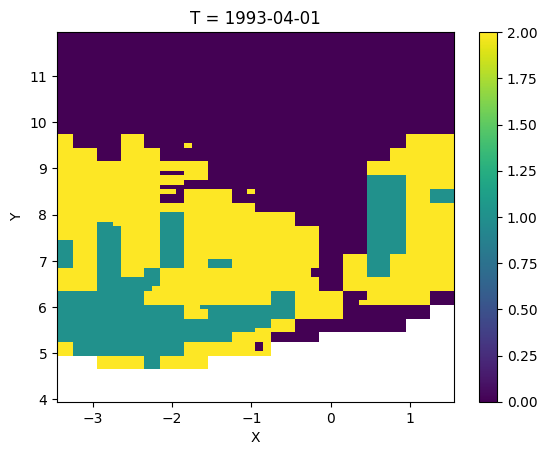

In [48]:
cluster.plot()

In [49]:
was_mme_gcm = WAS_Cross_Validator(n_splits=len(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))).get_index("T")), nb_omit=2)

In [50]:
if dist_method=="bestfit":
    hindcast_det_gcm, hindcast_prob_gcm, = was_mme_gcm.cross_validate(model, obs, all_model_hdcst, clim_year_start, 
                                                                  clim_year_end, best_params=best_params, cluster_da=cluster,
                                                                  best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
else:
    hindcast_det_gcm, hindcast_prob_gcm, = was_mme_gcm.cross_validate(model, obs, all_model_hdcst, clim_year_start,
                                                                  clim_year_end, best_params=best_params, cluster_da=cluster
                                                                     )    
hdcst_consolidated['SV-ML-CMME_ELM'] = hindcast_det_gcm
hdcst_consolidated_prob['SV-ML-CMME_ELM'] = hindcast_prob_gcm

Cross-validation ongoing


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24/24 [00:03<00:00,  7.48it/s]


#### Verification

In [51]:
score = ['Pearson', 'MAE']
model_name = "Extreme Learning Machine" #"Extreme Learning Machine" # Extreme Learning Machine "MultiLayer Perceptron" XGBoost Random Forest

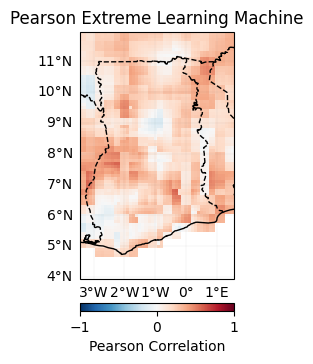

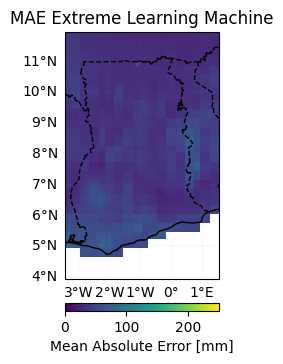

In [52]:
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        rainfall.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_det_gcm
    )
    scores_consolidated[i] = {'SV-ML-CMME_ELM': r}
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

##### Probabilistic

In [53]:
score = ['GROC', 'RPSS']

Generalized Discrimination Score


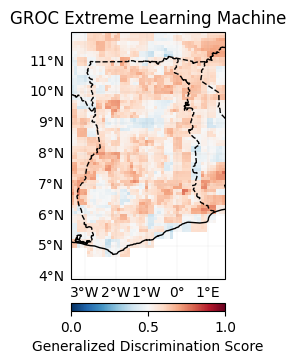

Ranked Probability Skill Score


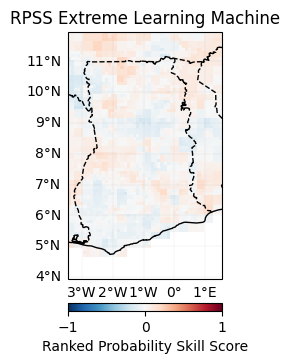

In [54]:
score = score.append('GROC') if 'GROC' not in score else score
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        rainfall.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_prob_gcm,
        clim_year_start,
        clim_year_end)
    scores_consolidated[i] = {'SV-ML-CMME_ELM': r}
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

#### Forecast 

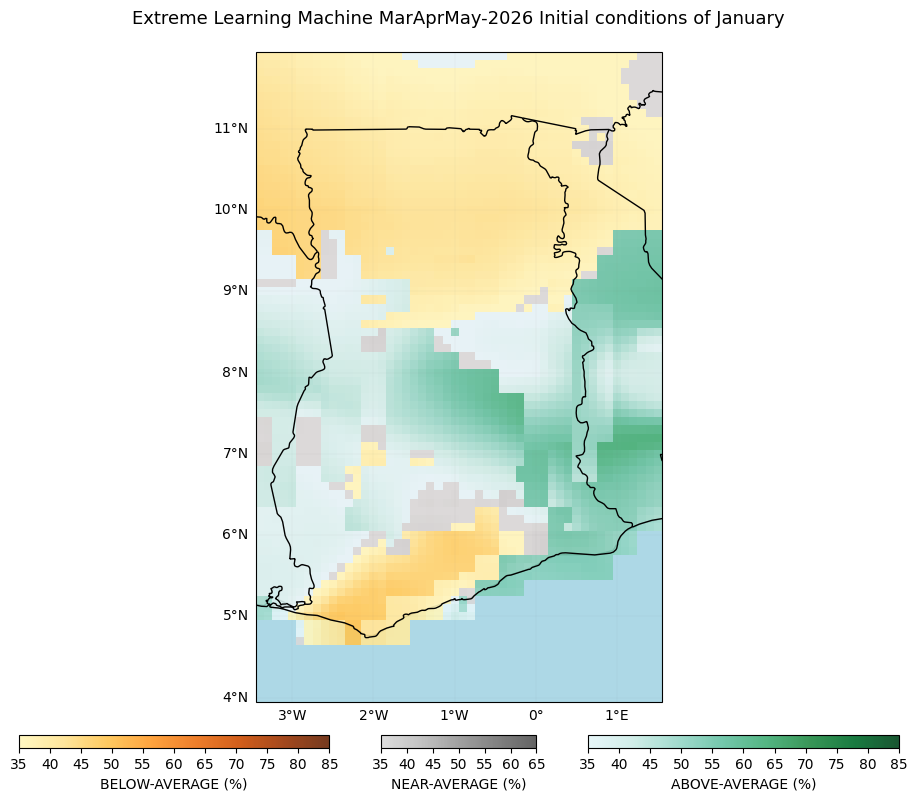

24931

In [55]:
if dist_method=="bestfit":
    forecast_det_gcm, forecast_prob_gcm= model.forecast(obs, clim_year_start, clim_year_end, all_model_hdcst, hindcast_det_gcm, all_model_fcst, best_params=best_params, cluster_da=cluster, 
                                                        best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
else:
    forecast_det_gcm, forecast_prob_gcm= model.forecast(obs, clim_year_start, clim_year_end, all_model_hdcst, hindcast_det_gcm, 
                                                        all_model_fcst, best_params=best_params, cluster_da=cluster
                                                       )
    
fcst_consolidated['SV-ML-CMME_ELM'] = forecast_det_gcm
fcst_consolidated_prob['SV-ML-CMME_ELM'] = forecast_prob_gcm
plot_prob_forecasts(f"{dir_to_forecast}", forecast_prob_gcm.drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast} Initial conditions of {calendar.month_name[int(month_of_initialization)]}",
                    hspace=0.1, labels=fcst_labels, reverse_cmap=False)
gc.collect()

In [56]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### XGBoost

In [57]:
model = WAS_mme_XGBoosting(
    search_method='bayesian',#'random',  # Use randomized search for efficiency
    n_estimators_range=[25, 50, 100, 200, 300, 500, 600, 700, 1000, 1500],# 3000, 5000],  # Optimized for climate data
    learning_rate_range=[0.01, 0.05, 0.1],  # Finer low values
    max_depth_range=[2, 3, 4, 5],  # Conservative depths
    min_child_weight_range=[1, 2, 5, 10],
    subsample_range=[0.6, 0.8, 1.0],
    colsample_bytree_range=[0.5, 0.7, 0.9, 1.0],
    gamma_range=[0, 0.001, 0.01, 0.1, 0.5, 1.0],  # ADDED: Regularization
    reg_alpha_range=[0, 0.1, 0.5, 1.0],  # ADDED: L1 regularization
    reg_lambda_range=[1, 3, 5, 10],  # ADDED: L2 regularization
    random_state=42,
    dist_method=dist_method,  # Use non-parametric for probabilities
    n_iter_search=1000,  # Increase iterations for better search
    cv_folds=5,
    n_clusters=3,  # Number of homogeneous zones
    optuna_n_jobs=-1,  # Use all cores if using bayesian optimization
    optuna_timeout=1200  # 20 minute timeout
)


#### Cross-validation

In [58]:
# all_model_hdcst, all_model_fcst, obs, best_score = process_datasets_for_mme(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))), gcm=True, ELM_ELR=True, dir_to_save_model=dir_to_save_model, best_models=best_models, scores=scores, year_start=year_start_model, year_end=year_end_model, model=True, month_of_initialization=month_of_initialization, lead_time=lead_time, year_forecast=forecast)
all_model_hdcst, all_model_fcst, obs, best_score = process_datasets_for_mme(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))), hdcsted=hindcast_files, fcsted=forecast_files, scores= scores, score_metric='MAE', gcm=True, agroparam=False, ELM_ELR=False, best_models=best_models, dir_to_save_model=dir_to_save_model, year_start=year_start_model, year_end=year_end_model, model=True, month_of_initialization=month_of_initialization, lead_time=lead_time, year_forecast=forecast)

In [ ]:
best_params, cluster = model.compute_hyperparameters(all_model_hdcst, obs, clim_year_start, clim_year_end)

[I 2026-02-10 00:16:57,953] A new study created in memory with name: no-name-ddcff1c9-e902-4e28-87d6-0efc6be4cde3


In [ ]:
best_params #= {'activation': 'lin', 'neurons': 200, 'norm': 37.38460883888426}

In [ ]:
cluster.plot()

In [ ]:
was_mme_gcm = WAS_Cross_Validator(n_splits=len(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))).get_index("T")), nb_omit=2)

In [ ]:
if dist_method=="bestfit":
    hindcast_det_gcm, hindcast_prob_gcm, = was_mme_gcm.cross_validate(model, obs, all_model_hdcst, clim_year_start, 
                                                                  clim_year_end, best_params=best_params, cluster_da=cluster,
                                                                  best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
else:
    hindcast_det_gcm, hindcast_prob_gcm, = was_mme_gcm.cross_validate(model, obs, all_model_hdcst, clim_year_start,
                                                                  clim_year_end, best_params=best_params, cluster_da=cluster
                                                                     )    
hdcst_consolidated['SV-ML-CMME_XGBOOST'] = hindcast_det_gcm
hdcst_consolidated_prob['SV-ML-CMME_XGBOOST'] = hindcast_prob_gcm

#### Verification

In [ ]:
score = ['Pearson', 'MAE']
model_name = "XGBoost" #"Extreme Learning Machine" # Extreme Learning Machine "MultiLayer Perceptron" XGBoost Random Forest

In [ ]:
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        rainfall.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_det_gcm
    )
    scores_consolidated[i] = {'SV-ML-CMME_XGBOOST': r}
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

##### Probabilistic

In [ ]:
score = ['GROC', 'RPSS']

In [ ]:
score = score.append('GROC') if 'GROC' not in score else score
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        rainfall.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_prob_gcm,
        clim_year_start,
        clim_year_end)
    scores_consolidated[i] = {'SV-ML-CMME_XGBOOST': r}
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

#### Forecast 

In [ ]:
if dist_method=="bestfit":
    forecast_det_gcm, forecast_prob_gcm= model.forecast(obs, clim_year_start, clim_year_end, all_model_hdcst, hindcast_det_gcm, all_model_fcst, best_params=best_params, cluster_da=cluster, 
                                                        best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
else:
    forecast_det_gcm, forecast_prob_gcm= model.forecast(obs, clim_year_start, clim_year_end, all_model_hdcst, hindcast_det_gcm, 
                                                        all_model_fcst, best_params=best_params, cluster_da=cluster
                                                       )
    
fcst_consolidated['SV-ML-CMME_XGBOOST'] = forecast_det_gcm
fcst_consolidated_prob['SV-ML-CMME_XGBOOST'] = forecast_prob_gcm
plot_prob_forecasts(f"{dir_to_forecast}", forecast_prob_gcm.drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast} Initial conditions of {calendar.month_name[int(month_of_initialization)]}",
                    hspace=0.1, labels=fcst_labels, reverse_cmap=False)
gc.collect()

# 2nd - Approach: CCA-Based Calibration VWIND

In [ ]:
# Filter model names to identify precipitation-related models
center_variable = [key for key in downloader.ModelsName().keys() if "VGRD_850" in key]
center_variable.remove('UKMO_603.VGRD_850')

# Specify the directory to save downloaded model data
dir_to_save_model = f"{dir_s2s}/model_data"

# Define the month for model initialization (June)
month_of_initialization = "01"

# Define lead times corresponding to seasonal forecast targets (JAS season in this case)
lead_time = ["03", "04", "05"]  # July-August-September forecast period

# Define the hindcast period for model data (years 1993 to 2016)
year_start_model = 1993
year_end_model = 2016

# Set the bounding box for the area of interest (latitude and longitude bounds)
extent = [60, -180, -60, 180]  # [Northern, Western, Southern and Eastern] 

# Define if you want to download forecast or hindcast
forecast = None

# Define if you want all members of ensemble or doing an ensemble mean
ensemble_mean = "mean"

# Specify whether to overwrite existing files when downloading data
force_download = False

In [ ]:
hindcast_files = downloader.WAS_Download_Models(
    dir_to_save_model,
    center_variable,
    month_of_initialization,
    lead_time,
    year_start_model,
    year_end_model,
    extent, 
    forecast,
    ensemble_mean,
    force_download)

In [ ]:
forecast = 2026

In [ ]:
forecast_files = downloader.WAS_Download_Models(
    dir_to_save_model,
    center_variable,
    month_of_initialization,
    lead_time,
    year_start_model,
    year_end_model,
    extent, 
    forecast,
    ensemble_mean,
    force_download)

In [ ]:
hindcast_files = {k: hindcast_files[k] for k in hindcast_files.keys() & forecast_files.keys()}
forecast_files = {k: forecast_files[k] for k in hindcast_files.keys() & forecast_files.keys()}
common_keys = {k.lower() for k in hindcast_files} & {k.lower() for k in forecast_files}
center_variable = [
    item
    for item in center_variable
    if any(item.lower().startswith(k) for k in list(common_keys))
                ]

In [ ]:
%load_ext autoreload
%autoreload 2

### Initialize the WAS_CCA class (default)

In [ ]:
n_modes = 3
# define zone as dict : {'zone_name_key': ('Explicit_Zone_name', lon_min, lon_max, lat_min, lat_max)} 
defined_zone = {'A': ('A', -60, 30, -50, 50)} 

In [ ]:
plot_map([extent[1],extent[3],extent[2],extent[0]], sst_indices = defined_zone, title="Predictors Area",fig_size=(6,4))

##### Modes of CCA for each model

In [ ]:
was_cca = WAS_CCA(n_modes=n_modes, n_pca_modes=8, dist_method=dist_method)
was_cv = WAS_Cross_Validator(n_splits=len(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))).get_index("T")), nb_omit=2)

In [ ]:
predictors = {}
for i in center_variable:
    predictors[i] = retrieve_single_zone_for_PCR(dir_to_save_model, defined_zone, i, year_start_model, year_end_model, clim_year_start=clim_year_start, clim_year_end=clim_year_end, model=True, month_of_initialization=month_of_initialization, lead_time=lead_time, standardize=True)
    predictor = predictors[i].isel(T = slice(None,-1))
    predictor['T'] = rainfall.sel(T=slice(str(year_start_model),str(year_end_model)))['T']
    print(f"CCA Modes for model {i}")
    was_cca.plot_cca_results(X=predictor, Y=rainfall.sel(T=slice(str(year_start_model),str(year_end_model))) , clim_year_start=clim_year_start, clim_year_end=clim_year_end)

#### Cross validation

In [ ]:
hindcast_det_dynam_all = {}
hindcast_prob_dynam_all = {}
for key, predictor in predictors.items():
    predictor = predictor.isel(T = slice(None,-1))
    predictor['T'] = rainfall.sel(T=slice(str(year_start_model),str(year_end_model)))['T']
    print(key.split('.')[0])
    if dist_method=="bestfit":
        hindcast_det_dynam_all[key], hindcast_prob_dynam_all[key] = was_cv.cross_validate(was_cca, rainfall.sel(T=slice(str(year_start_model),str(year_end_model))), 
                                                                                          predictor, clim_year_start, clim_year_end, best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
    else:
        hindcast_det_dynam_all[key], hindcast_prob_dynam_all[key] = was_cv.cross_validate(was_cca, rainfall.sel(T=slice(str(year_start_model),str(year_end_model))).sel(T=slice(str(year_start_model),str(year_end_model))), predictor, clim_year_start, clim_year_end) 

#### Verification (individual)

###### Deterministic

In [ ]:
score = ['Pearson','MAE']
model_name = "CCA-based"

In [ ]:
cca_scores = {}
for i in score:
    tmp = {}
    print(was_verify.scores[i][0])
    for key, hdcst in hindcast_det_dynam_all.items():
        tmp[f'{key}_snd.approach'] = was_verify.compute_deterministic_score(
            was_verify.get_scores_metadata()[i][5],
            rainfall.sel(T=slice(str(year_start_model),str(year_end_model))),
            hindcast_det_dynam_all[key]
        )
        was_verify.plot_model_score(tmp[f'{key}_snd.approach'], i, dir_save_score, f"{key}_{model_name}")
    cca_scores[i] = tmp

###### Probabilistic

In [ ]:
score = ['GROC', 'RPSS']

In [ ]:
score = score.append('GROC') if 'GROC' not in score else score
for i in score:
    tmp = {}
    print(was_verify.scores[i][0])
    for key, hdcst in hindcast_det_dynam_all.items():
        tmp[f'{key}_snd.approach'] = was_verify.compute_probabilistic_score(
            was_verify.get_scores_metadata()[i][5],
            rainfall.sel(T=slice(str(year_start_model),str(year_end_model))),
            hindcast_prob_dynam_all[key],
            clim_year_start,
            clim_year_end)
        was_verify.plot_model_score(tmp[f'{key}_snd.approach'], i, dir_save_score, f"{key}_{model_name}")
    cca_scores[i] = tmp

#### Forecast (individual)

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
forecast_det_dynam_all = {}
forecast_prob_dynam_all = {}
for key, predictor in predictors.items():
    predictor_f = predictor.isel(T=[-1])
    predictor = predictor.isel(T = slice(None,-1))
    predictor['T'] = rainfall.sel(T=slice(str(year_start_model),str(year_end_model)))['T']
    print(key.split('.')[0])
    if dist_method=="bestfit":
        forecast_det_dynam_all[key], forecast_prob_dynam_all[key] = was_cca.forecast(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))), clim_year_start, clim_year_end, predictor, hindcast_det_dynam_all[key], predictor_f, best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
    else:
        forecast_det_dynam_all[key], forecast_prob_dynam_all[key] = was_cca.forecast(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))), clim_year_start, clim_year_end, predictor, hindcast_det_dynam_all[key], predictor_f)
    model_name = f"CCA_{key.split('.')[0]}"    
    plot_prob_forecasts(f"{dir_to_forecast}",
                        forecast_prob_dynam_all[key].drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast} Initial conditions of {calendar.month_name[int(month_of_initialization)]}", 
                        hspace=0.1, labels=fcst_labels, reverse_cmap=False)

### Select best Statistico-Dynamical models

In [ ]:
#### Select some models
best_models = get_best_models(center_variable, cca_scores, metric='GROC', threshold=0.6, top_n=3, gcm=False)
best_models

In [ ]:
for key in best_models:
    hdcst_consolidated[f'{key}_snd.approach'] = hindcast_det_dynam_all[key]
    fcst_consolidated[f'{key}_snd.approach'] = forecast_det_dynam_all[key]
    hdcst_consolidated_prob[f'{key}_snd.approach'] = hindcast_prob_dynam_all[key]
    fcst_consolidated_prob[f'{key}_snd.approach'] = forecast_prob_dynam_all[key]
    
for metric, models in cca_scores.items():
    for model in list(models):                    # list() pour éviter RuntimeError
        if not any(model.startswith(p) for p in best_models):
            del models[model]

for key in cca_scores:
    scores_consolidated.setdefault(key, {}).update(cca_scores[key])

# 2nd - Approach: CCA-Based Calibration SST

In [ ]:
# Filter model names to identify precipitation-related models
center_variable = [key for key in downloader.ModelsName().keys() if "SST" in key]
# center_variable.remove('NASA_1.SST')
center_variable.remove('UKMO_603.SST')
# center_variable.remove('DWD_21.SST')
# center_variable.remove('CMC2_1.SST')
# center_variable.remove('METEOFRANCE_8.SST')

# Specify the directory to save downloaded model data
dir_to_save_model = f"{dir_s2s}/model_data"

# Define the month for model initialization (June)
month_of_initialization = "01"

# Define lead times corresponding to seasonal forecast targets (JAS season in this case)
lead_time = ["03", "04", "05"]  # July-August-September forecast period

# Define the hindcast period for model data (years 1993 to 2016)
year_start_model = 1993
year_end_model = 2016

# Set the bounding box for the area of interest (latitude and longitude bounds)
extent = [60, -180, -60, 180]  # [Northern, Western, Southern and Eastern] 

# Define if you want to download forecast or hindcast
forecast = None

# Define if you want all members of ensemble or doing an ensemble mean
ensemble_mean = "mean"

# Specify whether to overwrite existing files when downloading data
force_download = False

In [ ]:
hindcast_files = downloader.WAS_Download_Models(
    dir_to_save_model,
    center_variable,
    month_of_initialization,
    lead_time,
    year_start_model,
    year_end_model,
    extent, 
    forecast,
    ensemble_mean,
    force_download)

In [ ]:
forecast = 2026

In [ ]:
forecast_files = downloader.WAS_Download_Models(
    dir_to_save_model,
    center_variable,
    month_of_initialization,
    lead_time,
    year_start_model,
    year_end_model,
    extent, 
    forecast,
    ensemble_mean,
    force_download)

In [ ]:
hindcast_files = {k: hindcast_files[k] for k in hindcast_files.keys() & forecast_files.keys()}
forecast_files = {k: forecast_files[k] for k in hindcast_files.keys() & forecast_files.keys()}
common_keys = {k.lower() for k in hindcast_files} & {k.lower() for k in forecast_files}
center_variable = [
    item
    for item in center_variable
    if any(item.lower().startswith(k) for k in list(common_keys))
                ]

In [ ]:
%load_ext autoreload
%autoreload 2

### Initialize the WAS_CCA class (default)

In [ ]:
n_modes = 3
# define zone as dict : {'zone_name_key': ('Explicit_Zone_name', lon_min, lon_max, lat_min, lat_max)} 
defined_zone = {'A': ('A', -150, 150, -35, 35)}  

In [ ]:
plot_map([extent[1],extent[3],extent[2],extent[0]], sst_indices = defined_zone, title="Predictors Area",fig_size=(6,4))

##### Modes of CCA for each model

In [ ]:
was_cca = WAS_CCA(n_modes=n_modes, n_pca_modes=8, dist_method=dist_method)
was_cv = WAS_Cross_Validator(n_splits=len(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))).get_index("T")), nb_omit=2)

In [ ]:
predictors = {}
for i in center_variable:
    predictors[i] = retrieve_single_zone_for_PCR(dir_to_save_model, defined_zone, i, year_start_model, year_end_model, clim_year_start=clim_year_start, clim_year_end=clim_year_end, model=True, month_of_initialization=month_of_initialization, lead_time=lead_time, standardize=True)
    predictor = predictors[i].isel(T = slice(None,-1))
    predictor['T'] = rainfall.sel(T=slice(str(year_start_model),str(year_end_model)))['T']
    print(f"CCA Modes for model {i}")
    was_cca.plot_cca_results(X=predictor, Y=rainfall.sel(T=slice(str(year_start_model),str(year_end_model))) , clim_year_start=clim_year_start, clim_year_end=clim_year_end)

#### Cross validation

In [ ]:
hindcast_det_dynam_all = {}
hindcast_prob_dynam_all = {}
for key, predictor in predictors.items():
    predictor = predictor.isel(T = slice(None,-1))
    predictor['T'] = rainfall.sel(T=slice(str(year_start_model),str(year_end_model)))['T']
    print(key.split('.')[0])
    if dist_method=="bestfit":
        hindcast_det_dynam_all[key], hindcast_prob_dynam_all[key] = was_cv.cross_validate(was_cca, rainfall.sel(T=slice(str(year_start_model),str(year_end_model))), 
                                                                                          predictor, clim_year_start, clim_year_end, best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
    else:
        hindcast_det_dynam_all[key], hindcast_prob_dynam_all[key] = was_cv.cross_validate(was_cca, rainfall.sel(T=slice(str(year_start_model),str(year_end_model))).sel(T=slice(str(year_start_model),str(year_end_model))), predictor, clim_year_start, clim_year_end) 

#### Verification (individual)

###### Deterministic

In [ ]:
score = ['Pearson','MAE']
model_name = "CCA-based"

In [ ]:
cca_scores = {}
for i in score:
    tmp = {}
    print(was_verify.scores[i][0])
    for key, hdcst in hindcast_det_dynam_all.items():
        tmp[f'{key}_snd.approach'] = was_verify.compute_deterministic_score(
            was_verify.get_scores_metadata()[i][5],
            rainfall.sel(T=slice(str(year_start_model),str(year_end_model))),
            hindcast_det_dynam_all[key]
        )
        was_verify.plot_model_score(tmp[f'{key}_snd.approach'], i, dir_save_score, f"{key}_{model_name}")
    cca_scores[i] = tmp

###### Probabilistic

In [ ]:
score = ['GROC', 'RPSS']

In [ ]:
score = score.append('GROC') if 'GROC' not in score else score
for i in score:
    tmp = {}
    print(was_verify.scores[i][0])
    for key, hdcst in hindcast_det_dynam_all.items():
        tmp[f'{key}_snd.approach'] = was_verify.compute_probabilistic_score(
            was_verify.get_scores_metadata()[i][5],
            rainfall.sel(T=slice(str(year_start_model),str(year_end_model))),
            hindcast_prob_dynam_all[key],
            clim_year_start,
            clim_year_end)
        was_verify.plot_model_score(tmp[f'{key}_snd.approach'], i, dir_save_score, f"{key}_{model_name}")
    cca_scores[i] = tmp

#### Forecast (individual)

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
forecast_det_dynam_all = {}
forecast_prob_dynam_all = {}
for key, predictor in predictors.items():
    predictor_f = predictor.isel(T=[-1])
    predictor = predictor.isel(T = slice(None,-1))
    predictor['T'] = rainfall.sel(T=slice(str(year_start_model),str(year_end_model)))['T']
    print(key.split('.')[0])
    if dist_method=="bestfit":
        forecast_det_dynam_all[key], forecast_prob_dynam_all[key] = was_cca.forecast(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))), clim_year_start, clim_year_end, predictor, hindcast_det_dynam_all[key], predictor_f, best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
    else:
        forecast_det_dynam_all[key], forecast_prob_dynam_all[key] = was_cca.forecast(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))), clim_year_start, clim_year_end, predictor, hindcast_det_dynam_all[key], predictor_f)
    model_name = f"CCA_{key.split('.')[0]}"    
    plot_prob_forecasts(f"{dir_to_forecast}",
                        forecast_prob_dynam_all[key].drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast} Initial conditions of {calendar.month_name[int(month_of_initialization)]}", 
                        hspace=0.1, labels=fcst_labels, reverse_cmap=False)

### Select best Statistico-Dynamical models

In [ ]:
#### Select some models
best_models = get_best_models(center_variable, cca_scores, metric='GROC', threshold=0.6, top_n=3, gcm=False)
best_models

In [ ]:
for key in best_models:
    hdcst_consolidated[f'{key}_snd.approach'] = hindcast_det_dynam_all[key]
    fcst_consolidated[f'{key}_snd.approach'] = forecast_det_dynam_all[key]
    hdcst_consolidated_prob[f'{key}_snd.approach'] = hindcast_prob_dynam_all[key]
    fcst_consolidated_prob[f'{key}_snd.approach'] = forecast_prob_dynam_all[key]
    
for metric, models in cca_scores.items():
    for model in list(models):                    # list() pour éviter RuntimeError
        if not any(model.startswith(p) for p in best_models):
            del models[model]

for key in cca_scores:
    scores_consolidated.setdefault(key, {}).update(cca_scores[key])

# 3rd - Approach: Observation-Based with Lag (Obs-Lag) 

In [ ]:
# Filter model names to identify precipitation-related models
variables_reanalysis = ["NOAA.SST"] #[key for key in downloader.ReanalysisName().keys() if "SST" in key]# or "VGRD_850" in key]

# Specify the directory to save downloaded model data
dir_to_save_Reanalysis = f"{dir_s2s}/reanalysis_data/"

# choose sequence corresponding to seasonal forecast targets (JAS season in this case)
season = ["11","12","01"]  # Jan-Feb-Mar forecast period

# Define the observation period (years 1993 to 2016)
year_start = 1990
year_end = 2025

# Set the bounding box for the area of interest (latitude and longitude bounds)
extent = [60, -180, -60, 180]  # [Northern, Western, Southern and Eastern] 

# Specify whether to overwrite existing files when downloading data
force_download = False

In [ ]:
downloader.WAS_Download_Reanalysis(
    dir_to_save_Reanalysis,
    variables_reanalysis,
    year_start,
    year_end,
    extent,
    season, 
    force_download
)

## MLR with SST Indices

##### Process SST index 

In [ ]:
# Print available SST index
print(list(sst_indices_name.keys()))

In [ ]:
## Choose yours
sst_index_name = ['TNA', 'TSA', 'DMI', 'MB'] # 

# Set your own indices zones ( zones not available in built-in)
my_own_indices_zone = {
                         #'A': ('A', -55, 10, -20, 25),
                         # 'B': ('B', -170, -80, -10, 10),
                         # 'C': ('C', -10, 10, 1, 5),
                        }
others_zone = my_own_indices_zone

In [ ]:
# Combine all zones
sst_indices_all = {i: sst_indices_name[i] for i in sst_index_name} 
sst_indices_all.update(my_own_indices_zone) if my_own_indices_zone is not None else {i: sst_indices_name[i] for i in sst_index_name} 

In [ ]:
plot_map([extent[1],extent[3],extent[2],extent[0]], sst_indices = sst_indices_all, title="Index Zone",fig_size=(7,4))

In [ ]:
predictors = compute_sst_indices(dir_to_save_Reanalysis, sst_index_name, variables_reanalysis[0], year_start, year_end, season, clim_year_start, clim_year_end, my_own_indices_zone)

##### Calculate variance inflation factor to see multicolinearity predictor

In [ ]:
# Calculate VIF for each predictor
vif_data = pd.DataFrame()
vif_data["feature"] = predictors.to_dataframe().columns
vif_data["VIF"] = [VIF(predictors.to_dataframe(), i) for i in range(predictors.to_dataframe().shape[1])]
# Print VIF values
print(vif_data)

In [ ]:
# Set a threshold for VIF (e.g., 10)
vif_threshold = 5

In [ ]:
low_vif_predictors = vif_data[vif_data["VIF"] < vif_threshold]["feature"].tolist()
# Filter the predictors to exclude those with high VIF
filtered_predictors = predictors[low_vif_predictors].to_array()
filtered_predictors = filtered_predictors.rename({"variable": "features"}).transpose('T', 'features')
print(low_vif_predictors)

In [ ]:
# Available core over machine
cpu_count()

In [ ]:
#### Set core number for computation
nb_cores = 4

In [ ]:
# Load class for model, cross-validation and verification
model = WAS_LinearRegression_Model(nb_cores = nb_cores, dist_method=dist_method)

#### Cross validation

In [ ]:
# Instantiate cross-validation
was_cv = WAS_Cross_Validator(n_splits=len(rainfall.get_index("T")), nb_omit=2)

In [ ]:
filtered_predictors_ = filtered_predictors.isel(T = slice(None,-1))
filtered_predictors_['T'] = rainfall['T']
if dist_method=="bestfit":
    hindcast_det_obs_seas_mlr, hindcast_prob_obs_seas_mlr = was_cv.cross_validate(model, rainfall, filtered_predictors_, clim_year_start, clim_year_end, best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
else:
    hindcast_det_obs_seas_mlr, hindcast_prob_obs_seas_mlr = was_cv.cross_validate(model, rainfall, filtered_predictors_, clim_year_start, clim_year_end)
hdcst_consolidated['MLR_VIF.ERSST'] = hindcast_det_obs_seas_mlr.sel(T=slice(str(year_start_model),str(year_end_model)))
hdcst_consolidated_prob['MLR_VIF.ERSST'] = hindcast_prob_obs_seas_mlr.sel(T=slice(str(year_start_model),str(year_end_model)))

#### Verification

In [ ]:
score = ['Pearson','MAE']
model_name = "Observation-Based with Lag"

###### Deterministic

In [ ]:
third_scores = {}
hindcast_det_obsBased_all = {}
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        rainfall,
        hindcast_det_obs_seas_mlr
    )
    was_verify.plot_model_score(r, i, dir_save_score, model_name)
    scores_consolidated[i] = {'MLR_VIF.ERSST': r}
    third_scores[i] = {'MLR_VIF.SST': r}
hindcast_det_obsBased_all['MLR_VIF.ERSST'] = hindcast_det_obs_seas_mlr

###### Probabilistic

In [ ]:
score = ['GROC', 'RPSS']

In [ ]:
score = score.append('GROC') if 'GROC' not in score else score
hindcast_prob_obsBased_all = {}
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        rainfall,
        hindcast_prob_obs_seas_mlr,
        clim_year_start,
        clim_year_end)
    was_verify.plot_model_score(r, i, dir_save_score, model_name)
    third_scores[i] = {'MLR_VIF.SST': r}
    scores_consolidated[i] = {'MLR_VIF.ERSST': r}
    # scores_consolidated[i]['MLR_VIF.ERSST'] = r
hindcast_prob_obsBased_all['MLR_VIF.ERSST'] = hindcast_prob_obs_seas_mlr

#### Forecast

In [ ]:
forecast_det_obsBased_all = {}
forecast_prob_obsBased_all = {}
f_predictors = filtered_predictors.isel(T=[-1])
f_predictors['T'] = forecast_det_gcm['T']
if dist_method=="bestfit":
    forecast_det_mlr, forecast_prob_mlr = model.forecast(rainfall, clim_year_start, clim_year_end, filtered_predictors_, hindcast_det_obs_seas_mlr, f_predictors, best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
else:
    forecast_det_mlr, forecast_prob_mlr = model.forecast(rainfall, clim_year_start, clim_year_end, filtered_predictors_, hindcast_det_obs_seas_mlr, f_predictors)
    
forecast_det_obsBased_all['MLR_VIF.ERSST'] = forecast_det_mlr
forecast_prob_obsBased_all['MLR_VIF.ERSST'] = forecast_prob_mlr
fcst_consolidated['MLR_VIF.ERSST'] = forecast_det_mlr
fcst_consolidated_prob['MLR_VIF.ERSST'] = forecast_prob_mlr
plot_prob_forecasts(f"{dir_to_forecast}", 
                    forecast_prob_mlr.drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast} Initial conditions of {calendar.month_name[int(month_of_initialization)]}", 
                    hspace=0.1, labels=fcst_labels, reverse_cmap=False)

## CCA

In [ ]:
n_modes = 3
# Set your own zones ( zones not available in built-in)
# define zone as dict : {'zone_name_key': ('Explicit_Zone_name', lon_min, lon_max, lat_min, lat_max)} 
zones_for_PCR = {'A': ('A', -150, 100, -35, 35)}

In [ ]:
plot_map([extent[1],extent[3],extent[2],extent[0]], sst_indices = zones_for_PCR, title="Predictors Area",fig_size=(8,6))

In [ ]:
predictor = retrieve_single_zone_for_PCR(dir_to_save_Reanalysis, zones_for_PCR, variables_reanalysis[0], year_start, year_end, season, 1991, 2020, standardize=True)

In [ ]:
predictor = retrieve_single_zone_for_PCR(dir_to_save_Reanalysis, zones_for_PCR, variables_reanalysis[0], year_start, year_end, season, clim_year_start, clim_year_end)
predictor_f = predictor.isel(T=slice(None,-1))

In [ ]:
was_cca_ = WAS_CCA(n_modes=n_modes, n_pca_modes=6, dist_method=dist_method)
was_cv = was_cv = WAS_Cross_Validator(n_splits=len(rainfall.get_index("T")), nb_omit=2)

In [ ]:
was_cca_.plot_cca_results(X=predictor_f, Y=rainfall , clim_year_start=clim_year_start, clim_year_end=clim_year_end)

In [ ]:
predictor_f['T'] = rainfall['T']
if dist_method=="bestfit":
    hindcast_det_cca, hindcast_prob_cca = was_cv.cross_validate(was_cca_, rainfall, predictor_f, clim_year_start, clim_year_end, best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
else:
    hindcast_det_cca, hindcast_prob_cca = was_cv.cross_validate(was_cca_, rainfall, predictor_f, clim_year_start, clim_year_end)
hdcst_consolidated['CCA_ERSST'] = hindcast_det_cca.sel(T=slice(str(year_start_model),str(year_end_model)))
hdcst_consolidated_prob['CCA_ERSST'] = hindcast_prob_cca.sel(T=slice(str(year_start_model),str(year_end_model)))

### Verification

In [ ]:
score = ['Pearson','MAE']
# model_name = "Obs-Lag"

###### Deterministic

In [ ]:
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        rainfall,
        hindcast_det_cca
    )
    scores_consolidated[i] = {'CCA_ERSST': r}
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

###### Probabilistic

In [ ]:
score = ['GROC','RPSS']

In [ ]:
score = score.append('GROC') if 'GROC' not in score else score
hindcast_prob_obsBased_all = {}
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        rainfall,
        hindcast_prob_cca,
        clim_year_start,
        clim_year_end)
    scores_consolidated[i] = {'CCA_ERSST': r}      
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

### Forecast

In [ ]:
f_predictors = predictor.isel(T=[-1])
f_predictors['T'] = forecast_det_gcm['T']
if dist_method=="bestfit":
    forecast_det_cca, forecast_prob_cca = was_cca_.forecast(rainfall, clim_year_start, clim_year_end, predictor_f, hindcast_det_cca, f_predictors, best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
else:
    forecast_det_cca, forecast_prob_cca = was_cca_.forecast(rainfall, clim_year_start, clim_year_end, predictor_f, hindcast_det_cca, f_predictors)    
fcst_consolidated['CCA_ERSST'] = forecast_det_cca
fcst_consolidated_prob['CCA_ERSST'] = forecast_prob_cca
plot_prob_forecasts(f"{dir_to_forecast}", 
                    forecast_prob_cca.drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast} Initial conditions of {calendar.month_name[int(month_of_initialization)]}",
                    hspace=0.1, labels=fcst_labels,
                    reverse_cmap=False)

# 4th - Analog-based seasonal forecast

## Analog bias_based

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
model = WAS_Analog(
    dir_to_save=f"{dir_s2s}/analog",
    year_start=1990,
    year_forecast=2026,          # target forecast year
    month_of_initialization=1,   # May initialisation
    predictor_vars=[{'reanalysis_name': 'NOAA', 'model_name': 'ECMWF_51', 'variable': 'SST', 'area': [40, -180, -35, 100]},
                    # {'reanalysis_name': 'ERA5', 'model_name': 'NCEP_2', 'variable': 'SLP', 'area': [80, -60, -80, 60]},
                    # {'reanalysis_name': 'ERA5', 'model_name': 'NCEP_2', 'variable': 'VGRD_850', 'area': [30, -45, -20, 15]}
                   ],
    method_analog="bias_based",
    standardize=True,
    rolling=3,
    lead_time=[1,2,3],
    clim_year_start=clim_year_start, 
    clim_year_end=clim_year_end,
    dist_method=dist_method
)

#### Cross-validation

In [ ]:
was_analog_cv = WAS_Cross_Validator(n_splits=len(rainfall.get_index("T")), nb_omit=2)

In [ ]:
if dist_method=="bestfit":
    hindcast_analog_det, hindcast_analog_prob = was_analog_cv.cross_validate(model, rainfall, clim_year_start=clim_year_start, clim_year_end=clim_year_end, best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
else:
    hindcast_analog_det, hindcast_analog_prob = was_analog_cv.cross_validate(model, rainfall, clim_year_start=clim_year_start, clim_year_end=clim_year_end)    
hdcst_consolidated['fourth.approach'] = hindcast_analog_det.sel(T=slice(str(year_start_model),str(year_end_model)))
hdcst_consolidated_prob['fourth.approach'] = hindcast_analog_prob.sel(T=slice(str(year_start_model),str(year_end_model)))

#### Verification

###### Deterministic

In [ ]:
score = ['Pearson','MAE']
model_name = "Analogue-Based Forecasting"

In [ ]:
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        rainfall,
        hindcast_analog_det
    )
    scores_consolidated[i] = {'fourth.approach': r}
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

###### Probabilistic

In [ ]:
score = ['GROC', 'RPSS']

In [ ]:
score = score.append('GROC') if 'GROC' not in score else score
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        rainfall,
        hindcast_analog_prob,
        clim_year_start,
        clim_year_end)
    scores_consolidated[i] = {'fourth.approach': r}
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

#### Forecast

In [ ]:
## Analysis SST evolution
model.composite_plot(rainfall, clim_year_start, clim_year_end, 
                     hindcast_analog_det, plot_predictor=True,
                    variable="SST", best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)

In [ ]:
## Plot silimar years behavior
model.composite_plot(rainfall, clim_year_start, clim_year_end, hindcast_analog_det, plot_predictor=False, best_code_da=best_code_da,
                     best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)

In [ ]:
if dist_method=="bestfit":
    similar_years, forecast_det_analog, forecast_prob_analog = model.forecast(rainfall, clim_year_start, clim_year_end, hindcast_analog_det, best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
else:
    similar_years, forecast_det_analog, forecast_prob_analog = model.forecast(rainfall, clim_year_start, clim_year_end, hindcast_analog_det)    
fcst_consolidated['fourth.approach'] = forecast_det_analog
fcst_consolidated_prob['fourth.approach'] = forecast_prob_analog
plot_prob_forecasts(f"{dir_to_forecast}", forecast_prob_analog.drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast} Initial conditions of {calendar.month_name[int(month_of_initialization)]}",
                    hspace=0.1, labels=fcst_labels,
                    reverse_cmap=False)

# Consolidated Forecasts

In [ ]:
best_models = list(hdcst_consolidated.keys())
best_models 

#### Cross-validation

In [ ]:
all_model_hdcst, all_model_fcst, obs, best_score = process_datasets_for_mme(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))),hdcsted=hdcst_consolidated, fcsted=fcst_consolidated, gcm=False, ELM_ELR=False,  Prob=False, best_models=best_models, scores=scores_consolidated, model=False, score_metric="GROC")

In [ ]:
was_mme = WAS_mme_Weighted(equal_weighted=True, dist_method=dist_method, metric="GROC", threshold=0.6)

In [ ]:
hindcast_det, forecast_det  = was_mme.compute(obs, all_model_hdcst, all_model_fcst, best_score, complete=True)
hindcast_prob = was_mme.compute_prob(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))), clim_year_start, clim_year_end, hindcast_det, best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)

#### Verification

###### Deterministic

In [ ]:
score = ['Pearson','MAE']
model_name = "Consolidated Forecast"

In [ ]:
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        rainfall.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_det
    )
    
    r.to_dataset(name="Equaly weigthed")
    r.to_netcdf(f"{dir_s2s}/equaly_{i}.nc")
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

###### Probabilistic

In [ ]:
score = ['GROC', 'RPSS']

In [ ]:
score = score.append('GROC') if 'GROC' not in score else score
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        rainfall.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_prob,
        clim_year_start,
        clim_year_end)
    r.to_dataset(name="Equaly weigthed")
    r.to_netcdf(f"{dir_s2s}/equaly_{i}.nc")
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

### Forecast

In [ ]:
_,forecast_prob = was_mme.forecast(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))), clim_year_start, clim_year_end, hindcast_det, forecast_det,best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
plot_prob_forecasts(dir_to_forecast, forecast_prob.drop_vars('T').squeeze(),
                    f"{model_name} {season_str}-{forecast}" ,#issued {datetime.datetime.today().strftime("%Y-%m-%d")}", 
                    reverse_cmap=False,  hspace=0.1, labels=fcst_labels) # logo=logopath, logo_size=0.1,
gc.collect()

In [ ]:
plot_det_forecasts(forecast_det.drop_vars('T').squeeze(),
                    f"{model_name} Deterministic {season_str}-{forecast}", f"{dir_to_forecast}/{model_name} {season_str}-{forecast}.png")
gc.collect()

In [ ]:
forecast_det.to_netcdf(f'{dir_to_forecast}/Forecast_Det_PRCP{season_str}_{forecast}.nc')

In [ ]:
forecast_prob.to_netcdf(f'{dir_to_forecast}/Forecast_Prob_PRCP{season_str}_{forecast}.nc')

In [ ]:
!jupyter nbconvert --to html --no-input ./Template_seasonal_Ghana_MAM_2025.ipynb